In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
df = pd.read_csv('diabetes.csv')

In [4]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [5]:
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Shape: (768, 9)

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  

In [6]:
print(df.isnull().sum())


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [7]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("\nZero values count:")
for col in zero_cols:
    print(f"{col}: {(df[col] == 0).sum()}")



Zero values count:
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11


In [8]:
df[zero_cols] = df[zero_cols].replace(0, np.nan)

In [9]:
print(df.isnull().sum())


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [10]:
for col in zero_cols:
    df[col]=df[col].fillna(df[col].median())

In [11]:
print(df.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


/tmp/ipykernel_8821/3619820515.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette='Set2')


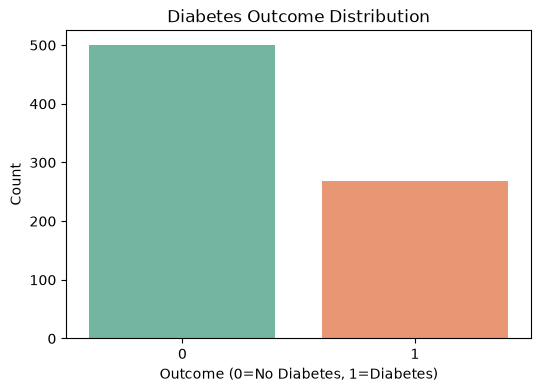

Outcome
0    500
1    268
Name: count, dtype: int64


In [13]:
# 1. Outcome distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df, palette='Set2')
plt.title('Diabetes Outcome Distribution')
plt.xlabel('Outcome (0=No Diabetes, 1=Diabetes)')
plt.ylabel('Count')
plt.show()

print(df['Outcome'].value_counts())

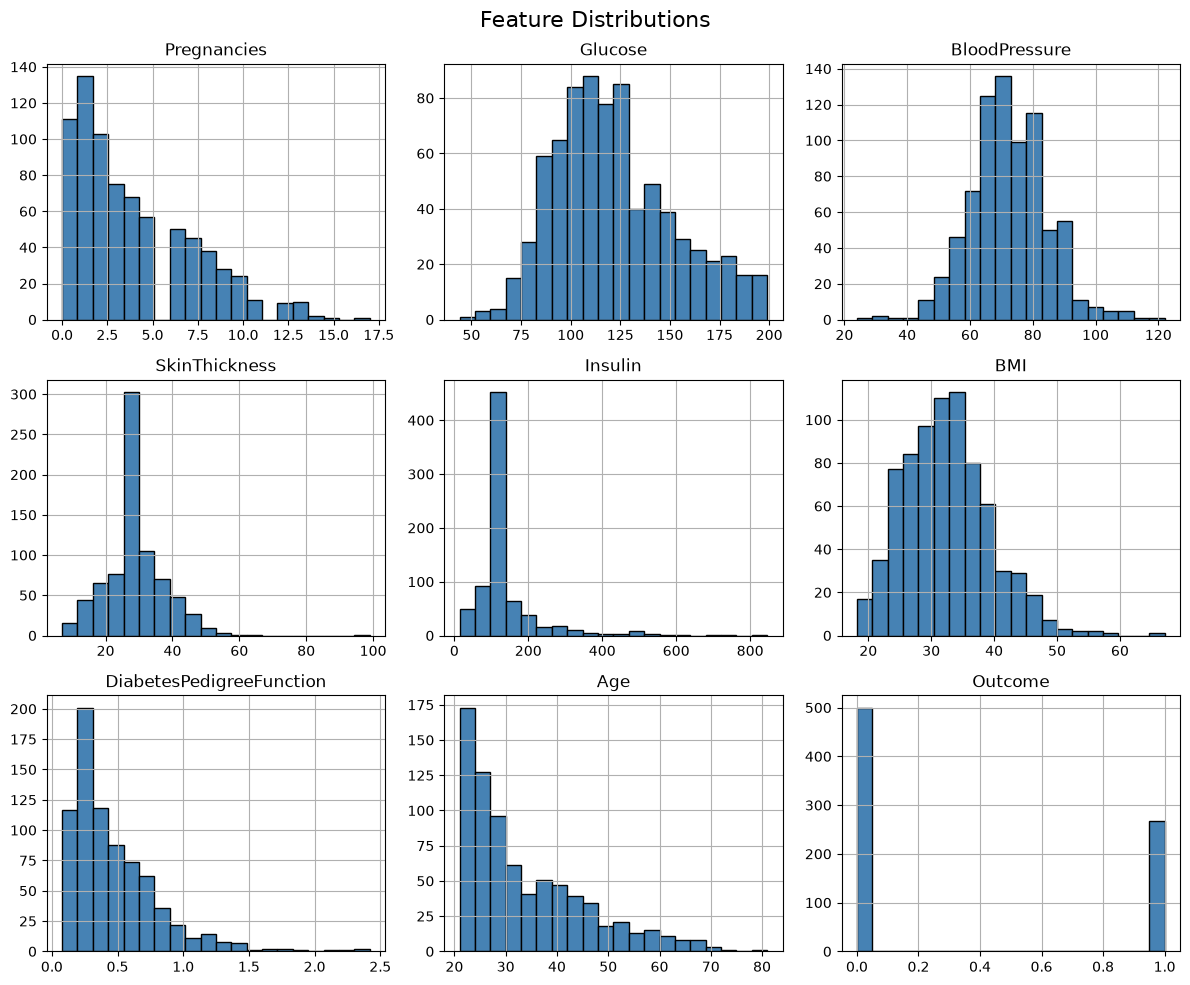

In [14]:
# 2. Histogram of all features
df.hist(figsize=(12, 10), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=16)
plt.tight_layout()
plt.show()

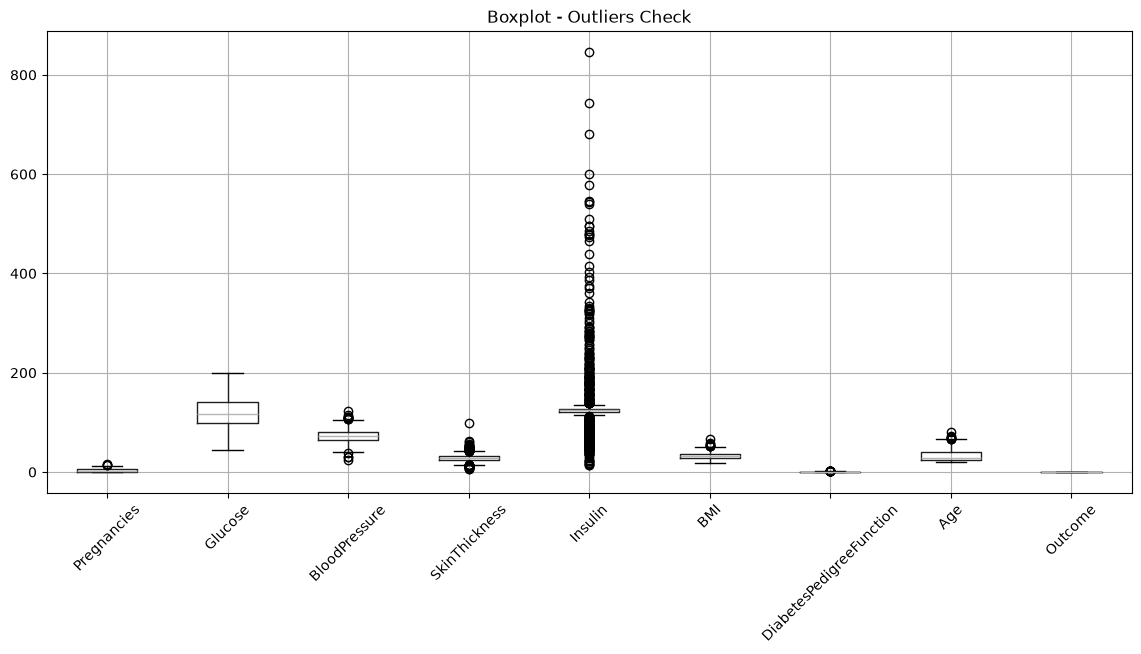

In [15]:
# 3. Boxplot - outliers dekhne ke liye
plt.figure(figsize=(14, 6))
df.boxplot()
plt.title('Boxplot - Outliers Check')
plt.xticks(rotation=45)
plt.show()

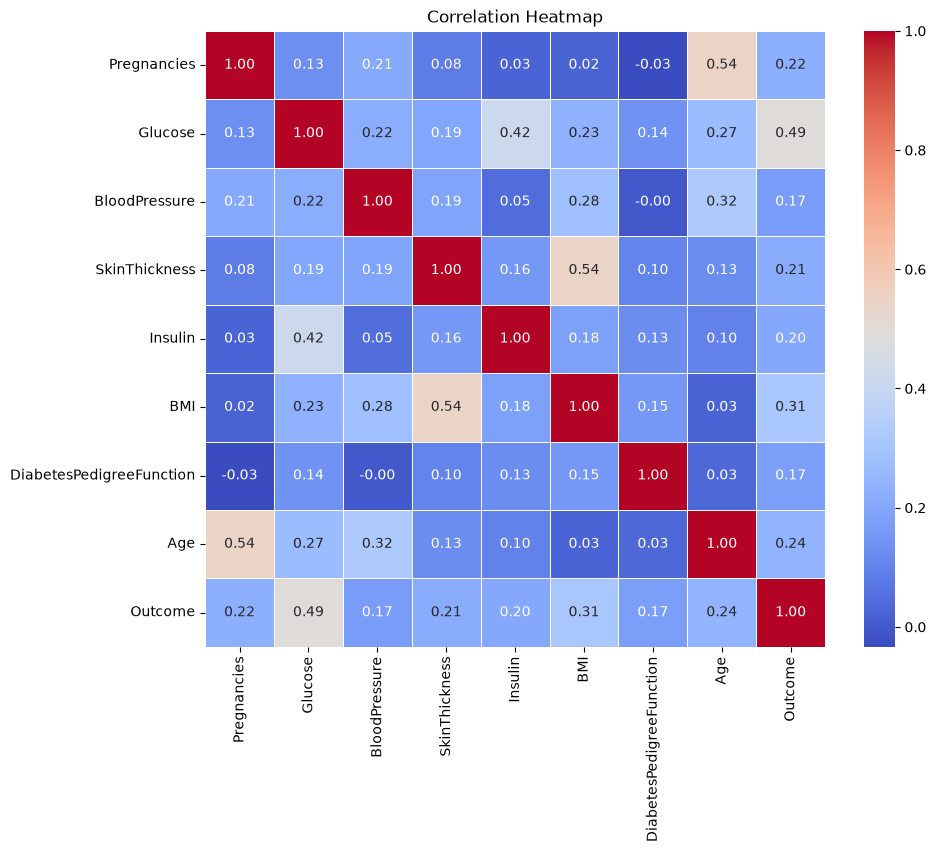

In [16]:
# 4. Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

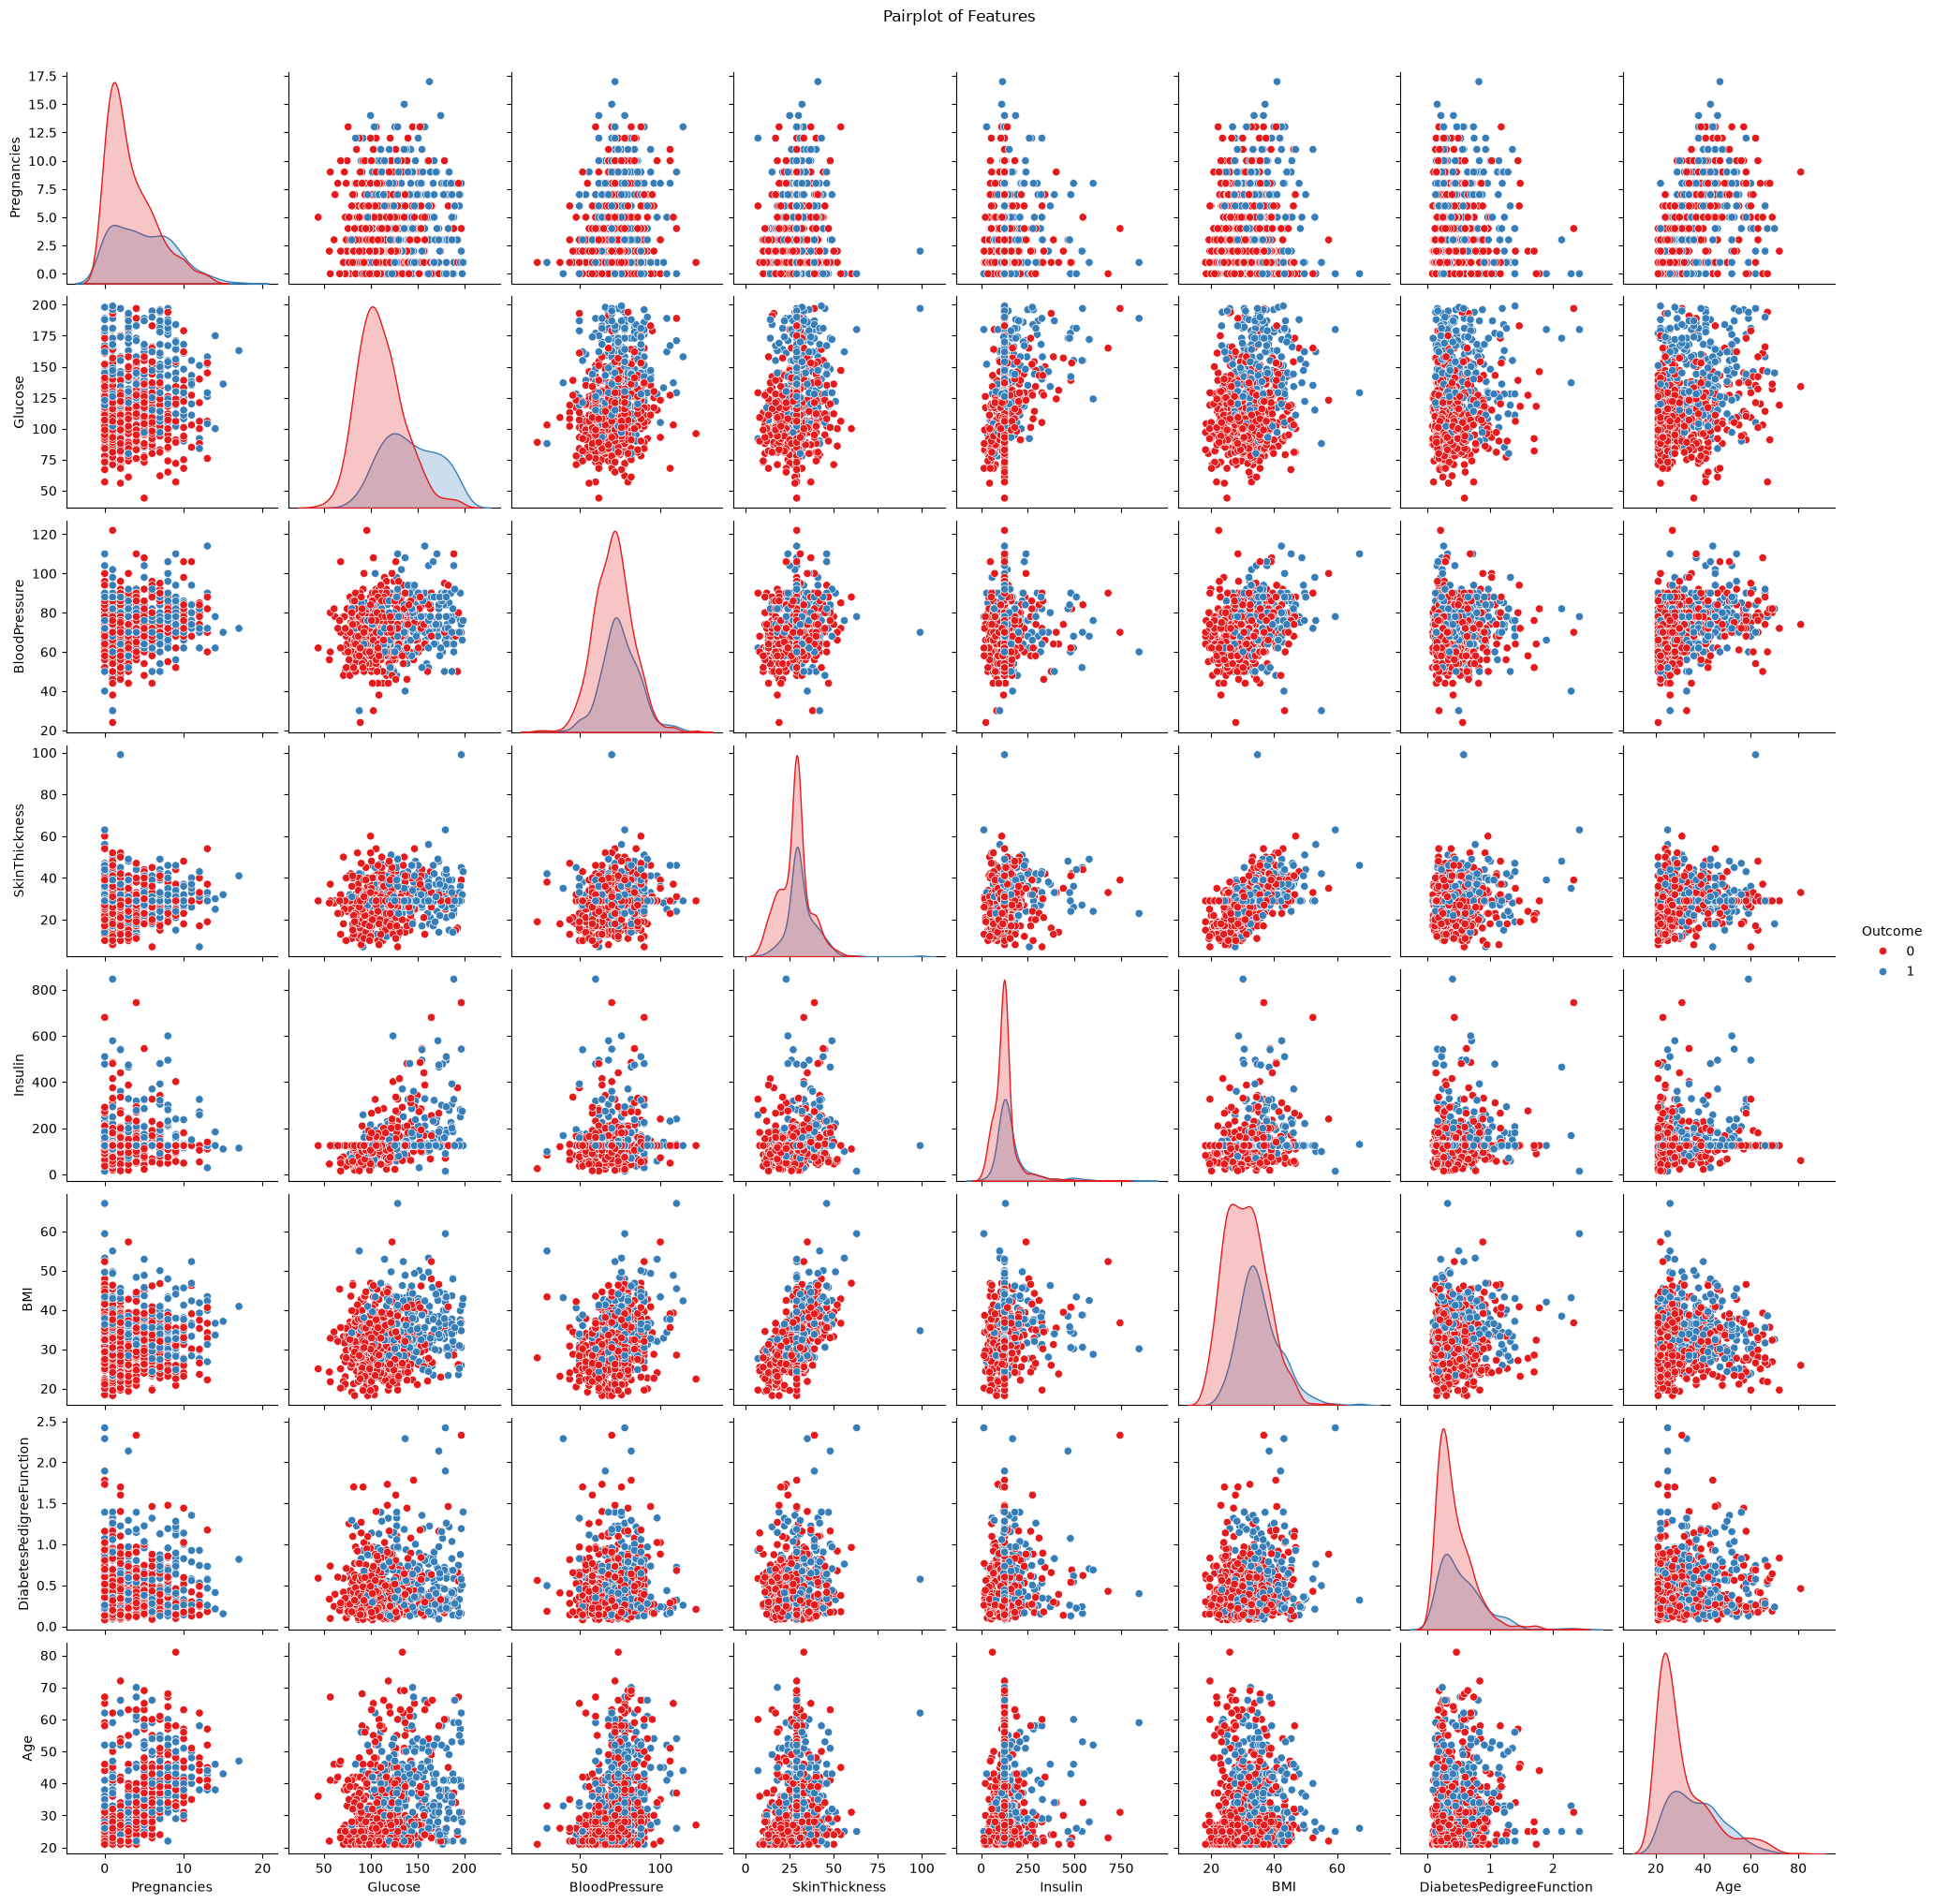

In [17]:
# 5. Pairplot
sns.pairplot(df, hue='Outcome', palette='Set1', diag_kind='kde')
plt.suptitle('Pairplot of Features', y=1.02)
plt.show()


/tmp/ipykernel_8821/2478522348.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='Glucose', data=df, palette='Set3')


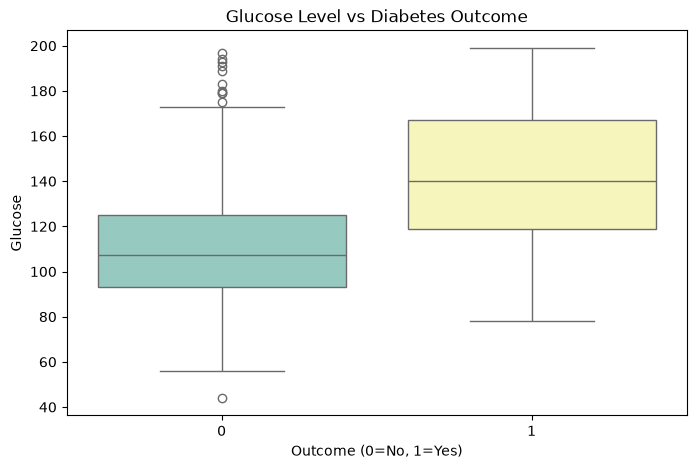

In [18]:
# 6. Glucose vs Outcome
plt.figure(figsize=(8, 5))
sns.boxplot(x='Outcome', y='Glucose', data=df, palette='Set3')
plt.title('Glucose Level vs Diabetes Outcome')
plt.xlabel('Outcome (0=No, 1=Yes)')
plt.show()

/tmp/ipykernel_8821/4073397025.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='Age', data=df, palette='pastel')


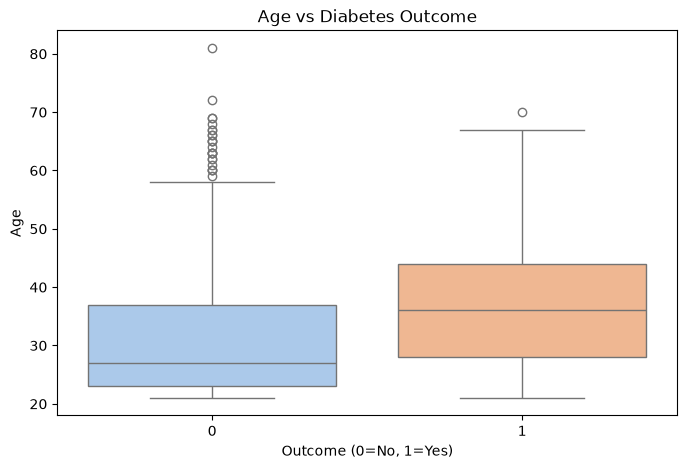

In [19]:
# 7. Age vs Outcome
plt.figure(figsize=(8, 5))
sns.boxplot(x='Outcome', y='Age', data=df, palette='pastel')
plt.title('Age vs Diabetes Outcome')
plt.xlabel('Outcome (0=No, 1=Yes)')
plt.show()

/tmp/ipykernel_8821/3475393309.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='BMI', data=df, palette='muted')


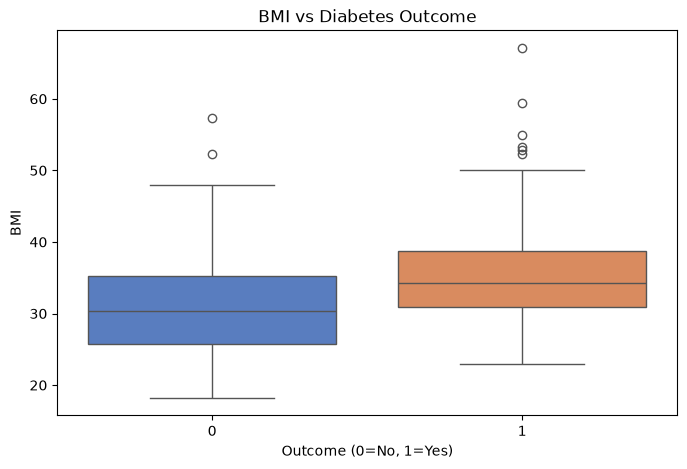

In [20]:
# 8. BMI vs Outcome
plt.figure(figsize=(8, 5))
sns.boxplot(x='Outcome', y='BMI', data=df, palette='muted')
plt.title('BMI vs Diabetes Outcome')
plt.xlabel('Outcome (0=No, 1=Yes)')
plt.show()

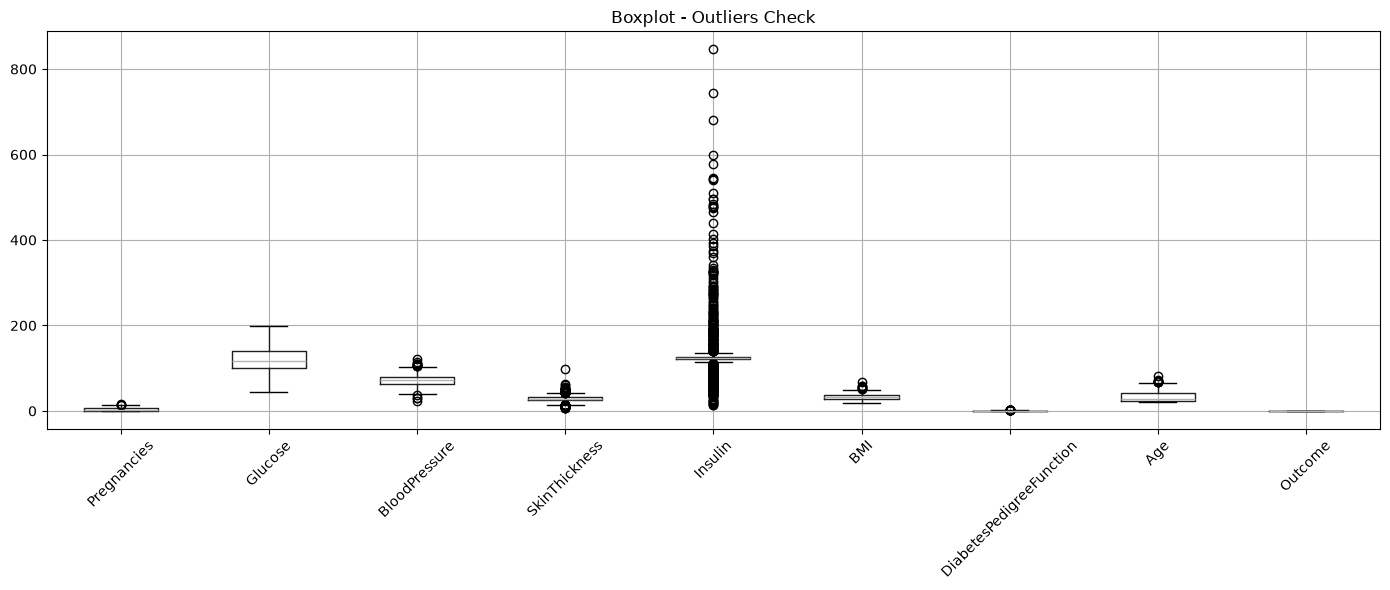

In [21]:
# Boxplot se outliers dekho
plt.figure(figsize=(14, 6))
df.boxplot()
plt.title('Boxplot - Outliers Check')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
# Har column mein kitne outliers hain
def count_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return len(outliers)

print("Outlier Count per Column:")
print("-" * 35)
for col in df.columns[:-1]:  # Outcome chod do
    count = count_outliers(df, col)
    percentage = (count / len(df)) * 100
    print(f"{col:30}: {count} ({percentage:.1f}%)")

Outlier Count per Column:
-----------------------------------
Pregnancies                   : 4 (0.5%)
Glucose                       : 0 (0.0%)
BloodPressure                 : 14 (1.8%)
SkinThickness                 : 87 (11.3%)
Insulin                       : 346 (45.1%)
BMI                           : 8 (1.0%)
DiabetesPedigreeFunction      : 29 (3.8%)
Age                           : 9 (1.2%)


In [23]:
# Dekho IQR boundaries kya hain Insulin ki
Q1 = df['Insulin'].quantile(0.25)
Q3 = df['Insulin'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Q1     : {Q1}")
print(f"Q3     : {Q3}")
print(f"IQR    : {IQR}")
print(f"Lower  : {lower}")
print(f"Upper  : {upper}")
print(f"95th % : {df['Insulin'].quantile(0.95)}")
print(f"Max    : {df['Insulin'].max()}")

Q1     : 121.5
Q3     : 127.25
IQR    : 5.75
Lower  : 112.875
Upper  : 135.875
95th % : 293.0
Max    : 846.0


In [24]:
print("Insulin Value Distribution:")
print("-" * 40)
print(f"Total rows      : {len(df)}")
print(f"Zero values     : {(df['Insulin'] == 0).sum()}")
print(f"Values 0-100    : {len(df[df['Insulin'] <= 100])}")
print(f"Values 101-200  : {len(df[(df['Insulin'] > 100) & (df['Insulin'] <= 200)])}")
print(f"Values 201-293  : {len(df[(df['Insulin'] > 200) & (df['Insulin'] <= 293)])}")
print(f"\nQ1 (25%)        : {df['Insulin'].quantile(0.25)}")
print(f"Median (50%)    : {df['Insulin'].quantile(0.50)}")
print(f"Q3 (75%)        : {df['Insulin'].quantile(0.75)}")
print(f"IQR Upper Bound : {upper}")

Insulin Value Distribution:
----------------------------------------
Total rows      : 768
Zero values     : 0
Values 0-100    : 151
Values 101-200  : 532
Values 201-293  : 47

Q1 (25%)        : 121.5
Median (50%)    : 125.0
Q3 (75%)        : 127.25
IQR Upper Bound : 135.875


In [25]:
print("Insulin value = 125 count:", 
      (df['Insulin'] == 125).sum())
print("Total rows:", len(df))
print(f"Percentage: {(df['Insulin']==125).sum()/len(df)*100:.1f}%")

Insulin value = 125 count: 378
Total rows: 768
Percentage: 49.2%


In [26]:
# X = input features
# y = output target

X = df.drop('Outcome', axis=1)
y = df['Outcome']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())
print("\nTarget:")
print(y.value_counts())

X shape: (768, 8)
y shape: (768,)

Features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target:
Outcome
0    500
1    268
Name: count, dtype: int64


/tmp/ipykernel_8821/3185248607.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='Set2')


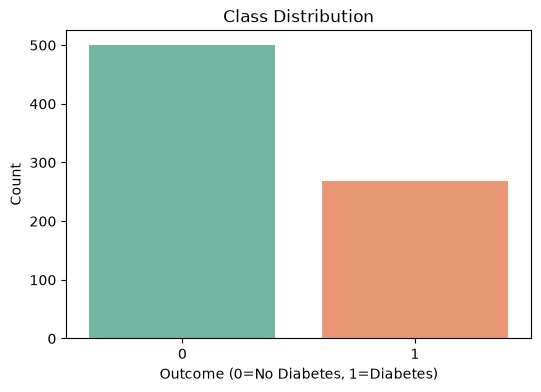


Class Distribution:
No Diabetes (0): 500 (65.1%)
Diabetes    (1): 268 (34.9%)


In [27]:
# Pehle dekho classes balanced hain ya nahi
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette='Set2')
plt.title('Class Distribution')
plt.xlabel('Outcome (0=No Diabetes, 1=Diabetes)')
plt.ylabel('Count')
plt.show()

print("\nClass Distribution:")
print(f"No Diabetes (0): {(y==0).sum()} ({(y==0).sum()/len(y)*100:.1f}%)")
print(f"Diabetes    (1): {(y==1).sum()} ({(y==1).sum()/len(y)*100:.1f}%)")

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # reproducibility
    stratify=y          # class balance maintain karo
)

print("Training set size  :", X_train.shape)
print("Testing set size   :", X_test.shape)

# Verify stratification
print("\nTrain class distribution:")
print(y_train.value_counts())
print("\nTest class distribution:")
print(y_test.value_counts())

Training set size  : (614, 8)
Testing set size   : (154, 8)

Train class distribution:
Outcome
0    400
1    214
Name: count, dtype: int64

Test class distribution:
Outcome
0    100
1     54
Name: count, dtype: int64


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data!
X_train = scaler.fit_transform(X_train)

# Transform test data
X_test = scaler.transform(X_test)

print("Scaling complete!")
print("\nAfter Scaling - X_train sample:")
print(X_train[:3])

Scaling complete!

After Scaling - X_train sample:
[[-0.85135507 -1.05642747 -0.82674004 -1.91818693 -1.20336073 -0.76947697
   0.31079384 -0.79216928]
 [ 0.35657564  0.14439907  0.47777235 -0.22987447 -1.47019479 -0.41749769
  -0.11643851  0.56103382]
 [-0.5493724  -0.55608308 -1.15286813  1.23332967 -0.55533518  0.3597899
  -0.76486207 -0.70759409]]


In [30]:
print("After Scaling Stats:")
print("-" * 35)
print(f"X_train Mean : {X_train.mean():.4f}  (should be ~0)")
print(f"X_train Std  : {X_train.std():.4f}   (should be ~1)")
print(f"X_test  Mean : {X_test.mean():.4f}")
print(f"X_test  Std  : {X_test.std():.4f}")

After Scaling Stats:
-----------------------------------
X_train Mean : -0.0000  (should be ~0)
X_train Std  : 1.0000   (should be ~1)
X_test  Mean : 0.0289
X_test  Std  : 1.0684


In [31]:
print("Column-wise Mean (Train):")
print(X_train.mean(axis=0))

print("\nColumn-wise Std (Train):")
print(X_train.std(axis=0))

Column-wise Mean (Train):
[-6.94341436e-17 -1.09937394e-16  3.09560557e-16 -3.47170718e-17
 -4.33963397e-18 -1.14855646e-15 -1.09937394e-16 -1.08490849e-16]

Column-wise Std (Train):
[1. 1. 1. 1. 1. 1. 1. 1.]


In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, 
                             roc_auc_score, classification_report,
                             confusion_matrix)

# Model banao
rf_model = RandomForestClassifier(
    n_estimators=100,    # 100 trees
    random_state=42,
    max_depth=5          # overfitting rokne ke liye
)

# Train karo
rf_model.fit(X_train, y_train)

# Predict karo
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Results
print("=" * 40)
print("RANDOM FOREST RESULTS")
print("=" * 40)
print(f"Accuracy  : {accuracy_score(y_test, rf_pred):.4f}")
print(f"Precision : {precision_score(y_test, rf_pred):.4f}")
print(f"Recall    : {recall_score(y_test, rf_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, rf_pred):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, rf_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

RANDOM FOREST RESULTS
Accuracy  : 0.7403
Precision : 0.6667
Recall    : 0.5185
F1 Score  : 0.5833
ROC AUC   : 0.8144

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.86      0.81       100
           1       0.67      0.52      0.58        54

    accuracy                           0.74       154
   macro avg       0.72      0.69      0.70       154
weighted avg       0.73      0.74      0.73       154



In [33]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
tf.random.set_seed(42)

# Model architecture
ann_model = Sequential([
    # Input + Hidden Layer 1
    Dense(16, activation='relu', input_dim=8),
    Dropout(0.3),
    
    # Hidden Layer 2
    Dense(8, activation='relu'),
    Dropout(0.2),
    
    # Output Layer
    Dense(1, activation='sigmoid')
])

# Compile
ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Model summary
ann_model.summary()

I0000 00:00:1785968770.797217    8821 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785968771.722446    8821 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785968774.620299    8821 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/ded_yeyyy/miniconda3/envs/ml/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1785968775.100803    8821 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA erro

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
# Early stopping - overfitting rokne ke liye
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train
history = ann_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4379 - loss: 0.7674 - val_accuracy: 0.4472 - val_loss: 0.7206
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4786 - loss: 0.7370 - val_accuracy: 0.5041 - val_loss: 0.6892
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5173 - loss: 0.7148 - val_accuracy: 0.6341 - val_loss: 0.6637
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5988 - loss: 0.6791 - val_accuracy: 0.6585 - val_loss: 0.6430
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6538 - loss: 0.6574 - val_accuracy: 0.7073 - val_loss: 0.6239
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6456 - loss: 0.6394 - val_accuracy: 0.6992 - val_loss: 0.6069
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6741 - loss: 0.6218 - val_accuracy: 0.6992 - val_loss: 0.5911
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6741 - loss: 0.6020 - val_accuracy: 0.6992 -

In [35]:
# Predict
ann_prob = ann_model.predict(X_test)
ann_pred = (ann_prob > 0.5).astype(int)

# Results
print("=" * 40)
print("ANN RESULTS")
print("=" * 40)
print(f"Accuracy  : {accuracy_score(y_test, ann_pred):.4f}")
print(f"Precision : {precision_score(y_test, ann_pred):.4f}")
print(f"Recall    : {recall_score(y_test, ann_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, ann_pred):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, ann_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, ann_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
ANN RESULTS
Accuracy  : 0.7338
Precision : 0.6327
Recall    : 0.5741
F1 Score  : 0.6019
ROC AUC   : 0.8202

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.82      0.80       100
           1       0.63      0.57      0.60        54

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



In [36]:
print("\n")
print("=" * 50)
print("        FINAL COMPARISON TABLE")
print("=" * 50)
print(f"{'Metric':<15} {'Random Forest':>15} {'ANN':>15}")
print("-" * 50)
print(f"{'Accuracy':<15} {accuracy_score(y_test, rf_pred):>15.4f} {accuracy_score(y_test, ann_pred):>15.4f}")
print(f"{'Precision':<15} {precision_score(y_test, rf_pred):>15.4f} {precision_score(y_test, ann_pred):>15.4f}")
print(f"{'Recall':<15} {recall_score(y_test, rf_pred):>15.4f} {recall_score(y_test, ann_pred):>15.4f}")
print(f"{'F1 Score':<15} {f1_score(y_test, rf_pred):>15.4f} {f1_score(y_test, ann_pred):>15.4f}")
print(f"{'ROC AUC':<15} {roc_auc_score(y_test, rf_prob):>15.4f} {roc_auc_score(y_test, ann_prob):>15.4f}")
print("=" * 50)



        FINAL COMPARISON TABLE
Metric            Random Forest             ANN
--------------------------------------------------
Accuracy                 0.7403          0.7338
Precision                0.6667          0.6327
Recall                   0.5185          0.5741
F1 Score                 0.5833          0.6019
ROC AUC                  0.8144          0.8202


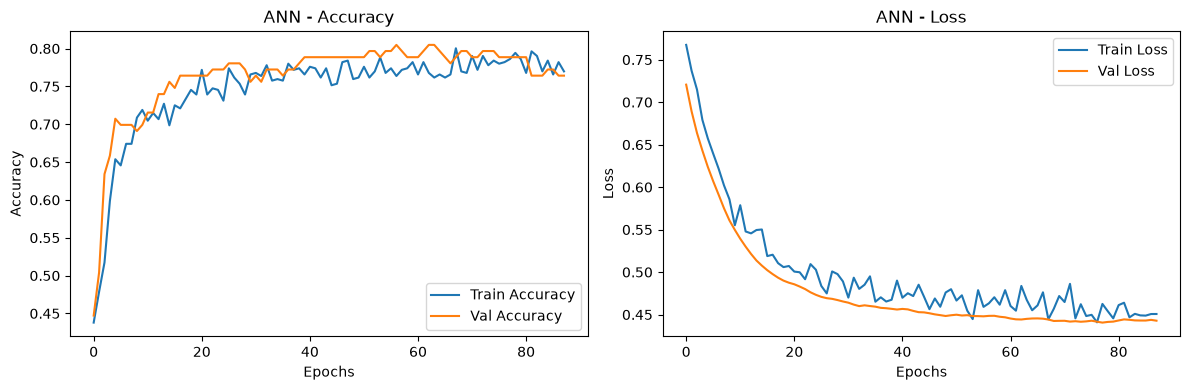

In [37]:
# Training history plot
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('ANN - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('ANN - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

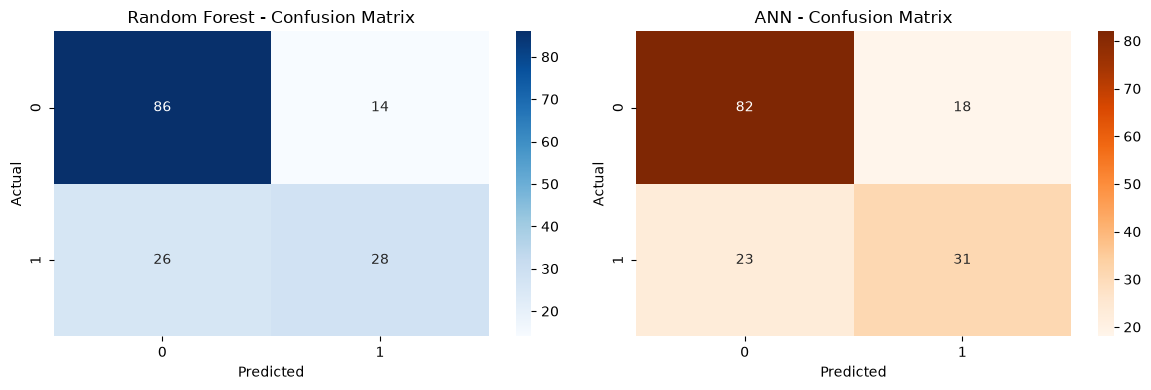

In [38]:
# Confusion Matrix dono ke liye
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Random Forest CM
sns.heatmap(confusion_matrix(y_test, rf_pred), 
            annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Random Forest - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ANN CM
sns.heatmap(confusion_matrix(y_test, ann_pred), 
            annot=True, fmt='d', cmap='Oranges', ax=axes[1])
axes[1].set_title('ANN - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

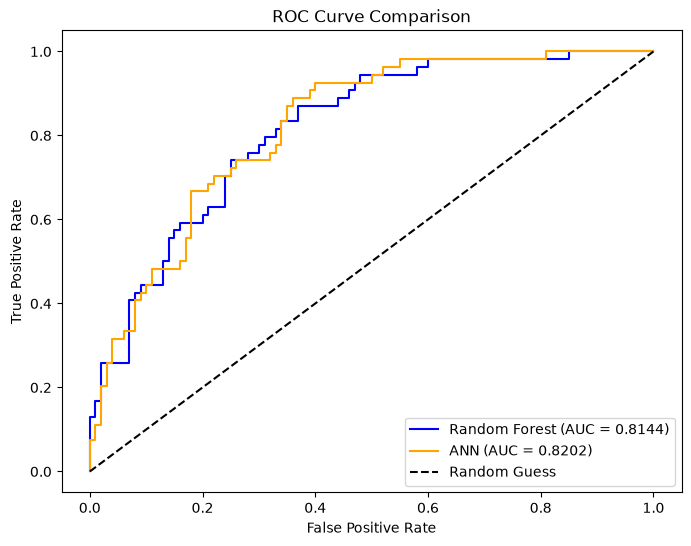

In [39]:
from sklearn.metrics import roc_curve

# ROC curves
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
ann_fpr, ann_tpr, _ = roc_curve(y_test, ann_prob)

plt.figure(figsize=(8, 6))
plt.plot(rf_fpr, rf_tpr, 
         label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.4f})',
         color='blue')
plt.plot(ann_fpr, ann_tpr, 
         label=f'ANN (AUC = {roc_auc_score(y_test, ann_prob):.4f})',
         color='orange')
plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [40]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Class weights compute karo
classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weight_dict = dict(zip(classes, weights))
print("Class Weights:", class_weight_dict)

# ANN retrain with class weights
tf.random.set_seed(42)

ann_model_v2 = Sequential([
    Dense(16, activation='relu', input_dim=8),
    Dropout(0.3),
    Dense(8, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

ann_model_v2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history_v2 = ann_model_v2.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weight_dict,  # ← Ye add kiya
    verbose=1
)

Class Weights: {np.int64(0): np.float64(0.7675), np.int64(1): np.float64(1.4345794392523366)}
Epoch 1/100


/home/ded_yeyyy/miniconda3/envs/ml/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5397 - loss: 0.7015 - val_accuracy: 0.5854 - val_loss: 0.6649
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5845 - loss: 0.6827 - val_accuracy: 0.6585 - val_loss: 0.6471
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6110 - loss: 0.6754 - val_accuracy: 0.6585 - val_loss: 0.6289
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6232 - loss: 0.6601 - val_accuracy: 0.6829 - val_loss: 0.6112
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6497 - loss: 0.6307 - val_accuracy: 0.7073 - val_loss: 0.5956
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6741 - loss: 0.6305 - val_accuracy: 0.6992 - val_loss: 0.5801
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7026 - loss: 0.6298 - val_accuracy: 0.7073 - val_loss: 0.5664
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6802 - loss: 0.6236 - val_accuracy: 0.7073 - val_loss: 0.

In [43]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(f"Class 0: {(y_train==0).sum()}")
print(f"Class 1: {(y_train==1).sum()}")

print("\nAfter SMOTE:")
print(f"Class 0: {(y_train_sm==0).sum()}")
print(f"Class 1: {(y_train_sm==1).sum()}")

Before SMOTE:
Class 0: 400
Class 1: 214

After SMOTE:
Class 0: 400
Class 1: 400


In [44]:
# Predict
ann_prob_v2 = ann_model_v2.predict(X_test)
ann_pred_v2 = (ann_prob_v2 > 0.5).astype(int)

print("=" * 50)
print("      IMPROVED COMPARISON TABLE")
print("=" * 50)
print(f"{'Metric':<15} {'RF':>10} {'ANN v1':>10} {'ANN v2':>10}")
print("-" * 50)
print(f"{'Accuracy':<15} {accuracy_score(y_test, rf_pred):>10.4f} {accuracy_score(y_test, ann_pred):>10.4f} {accuracy_score(y_test, ann_pred_v2):>10.4f}")
print(f"{'Precision':<15} {precision_score(y_test, rf_pred):>10.4f} {precision_score(y_test, ann_pred):>10.4f} {precision_score(y_test, ann_pred_v2):>10.4f}")
print(f"{'Recall':<15} {recall_score(y_test, rf_pred):>10.4f} {recall_score(y_test, ann_pred):>10.4f} {recall_score(y_test, ann_pred_v2):>10.4f}")
print(f"{'F1 Score':<15} {f1_score(y_test, rf_pred):>10.4f} {f1_score(y_test, ann_pred):>10.4f} {f1_score(y_test, ann_pred_v2):>10.4f}")
print(f"{'ROC AUC':<15} {roc_auc_score(y_test, rf_prob):>10.4f} {roc_auc_score(y_test, ann_prob):>10.4f} {roc_auc_score(y_test, ann_prob_v2):>10.4f}")
print("=" * 50)

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
      IMPROVED COMPARISON TABLE
Metric                  RF     ANN v1     ANN v2
--------------------------------------------------
Accuracy            0.7403     0.7338     0.7338
Precision           0.6667     0.6327     0.5867
Recall              0.5185     0.5741     0.8148
F1 Score            0.5833     0.6019     0.6822
ROC AUC             0.8144     0.8202     0.8030


In [45]:
tf.random.set_seed(42)

ann_model_v3 = Sequential([
    Dense(16, activation='relu', input_dim=8),
    Dropout(0.3),
    Dense(8, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

ann_model_v3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# SMOTE data pe train karo
history_v3 = ann_model_v3.fit(
    X_train_sm, y_train_sm,    # ← SMOTE data
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Predict - original test data pe!
ann_prob_v3 = ann_model_v3.predict(X_test)
ann_pred_v3 = (ann_prob_v3 > 0.5).astype(int)

# Final comparison
print("=" * 60)
print("           FINAL COMPARISON TABLE")
print("=" * 60)
print(f"{'Metric':<15} {'RF':>10} {'ANN v1':>10} {'ANN v2':>10} {'ANN v3':>10}")
print("-" * 60)
print(f"{'Accuracy':<15} {accuracy_score(y_test, rf_pred):>10.4f} {accuracy_score(y_test, ann_pred):>10.4f} {accuracy_score(y_test, ann_pred_v2):>10.4f} {accuracy_score(y_test, ann_pred_v3):>10.4f}")
print(f"{'Precision':<15} {precision_score(y_test, rf_pred):>10.4f} {precision_score(y_test, ann_pred):>10.4f} {precision_score(y_test, ann_pred_v2):>10.4f} {precision_score(y_test, ann_pred_v3):>10.4f}")
print(f"{'Recall':<15} {recall_score(y_test, rf_pred):>10.4f} {recall_score(y_test, ann_pred):>10.4f} {recall_score(y_test, ann_pred_v2):>10.4f} {recall_score(y_test, ann_pred_v3):>10.4f}")
print(f"{'F1 Score':<15} {f1_score(y_test, rf_pred):>10.4f} {f1_score(y_test, ann_pred):>10.4f} {f1_score(y_test, ann_pred_v2):>10.4f} {f1_score(y_test, ann_pred_v3):>10.4f}")
print(f"{'ROC AUC':<15} {roc_auc_score(y_test, rf_prob):>10.4f} {roc_auc_score(y_test, ann_prob):>10.4f} {roc_auc_score(y_test, ann_prob_v2):>10.4f} {roc_auc_score(y_test, ann_prob_v3):>10.4f}")
print("=" * 60)

Epoch 1/100


/home/ded_yeyyy/miniconda3/envs/ml/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6062 - loss: 0.6598 - val_accuracy: 0.2125 - val_loss: 0.8447
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6016 - loss: 0.6438 - val_accuracy: 0.1750 - val_loss: 0.8414
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6313 - loss: 0.6024 - val_accuracy: 0.1625 - val_loss: 0.8427
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6562 - loss: 0.5864 - val_accuracy: 0.1688 - val_loss: 0.8385
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6516 - loss: 0.5894 - val_accuracy: 0.2062 - val_loss: 0.8253
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6438 - loss: 0.5785 - val_accuracy: 0.2375 - val_loss: 0.8062
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6719 - loss: 0.5598 - val_accuracy: 0.2812 - val_loss: 0.7983
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6953 - loss: 0.5578 - val_accuracy: 0.3500 - val_loss: 0

In [46]:
tf.random.set_seed(42)

ann_model_v4 = Sequential([
    Dense(16, activation='relu', input_dim=8),
    Dropout(0.3),
    Dense(8, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

ann_model_v4.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# SMOTE data + Class Weight dono!
history_v4 = ann_model_v4.fit(
    X_train_sm, y_train_sm,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weight_dict,  # ← dono!
    verbose=1
)

# Predict
ann_prob_v4 = ann_model_v4.predict(X_test)
ann_pred_v4 = (ann_prob_v4 > 0.5).astype(int)

print("=" * 70)
print("                    COMPLETE FINAL TABLE")
print("=" * 70)
print(f"{'Metric':<15} {'RF':>10} {'ANN v1':>10} {'ANN v2':>10} {'ANN v3':>10} {'ANN v4':>10}")
print("-" * 70)
print(f"{'Accuracy':<15} {accuracy_score(y_test, rf_pred):>10.4f} {accuracy_score(y_test, ann_pred):>10.4f} {accuracy_score(y_test, ann_pred_v2):>10.4f} {accuracy_score(y_test, ann_pred_v3):>10.4f} {accuracy_score(y_test, ann_pred_v4):>10.4f}")
print(f"{'Precision':<15} {precision_score(y_test, rf_pred):>10.4f} {precision_score(y_test, ann_pred):>10.4f} {precision_score(y_test, ann_pred_v2):>10.4f} {precision_score(y_test, ann_pred_v3):>10.4f} {precision_score(y_test, ann_pred_v4):>10.4f}")
print(f"{'Recall':<15} {recall_score(y_test, rf_pred):>10.4f} {recall_score(y_test, ann_pred):>10.4f} {recall_score(y_test, ann_pred_v2):>10.4f} {recall_score(y_test, ann_pred_v3):>10.4f} {recall_score(y_test, ann_pred_v4):>10.4f}")
print(f"{'F1 Score':<15} {f1_score(y_test, rf_pred):>10.4f} {f1_score(y_test, ann_pred):>10.4f} {f1_score(y_test, ann_pred_v2):>10.4f} {f1_score(y_test, ann_pred_v3):>10.4f} {f1_score(y_test, ann_pred_v4):>10.4f}")
print(f"{'ROC AUC':<15} {roc_auc_score(y_test, rf_prob):>10.4f} {roc_auc_score(y_test, ann_prob):>10.4f} {roc_auc_score(y_test, ann_prob_v2):>10.4f} {roc_auc_score(y_test, ann_prob_v3):>10.4f} {roc_auc_score(y_test, ann_prob_v4):>10.4f}")
print("=" * 70)

Epoch 1/100


/home/ded_yeyyy/miniconda3/envs/ml/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4719 - loss: 0.7158 - val_accuracy: 0.7625 - val_loss: 0.5934
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4891 - loss: 0.7121 - val_accuracy: 0.8500 - val_loss: 0.5541
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5406 - loss: 0.6804 - val_accuracy: 0.9312 - val_loss: 0.5307
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5797 - loss: 0.6596 - val_accuracy: 0.9438 - val_loss: 0.5132
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5797 - loss: 0.6520 - val_accuracy: 0.9125 - val_loss: 0.4995
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6219 - loss: 0.6464 - val_accuracy: 0.8875 - val_loss: 0.4922
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6609 - loss: 0.6173 - val_accuracy: 0.8687 - val_loss: 0.4838
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6281 - loss: 0.6215 - val_accuracy: 0.8313 - val_loss: 0.

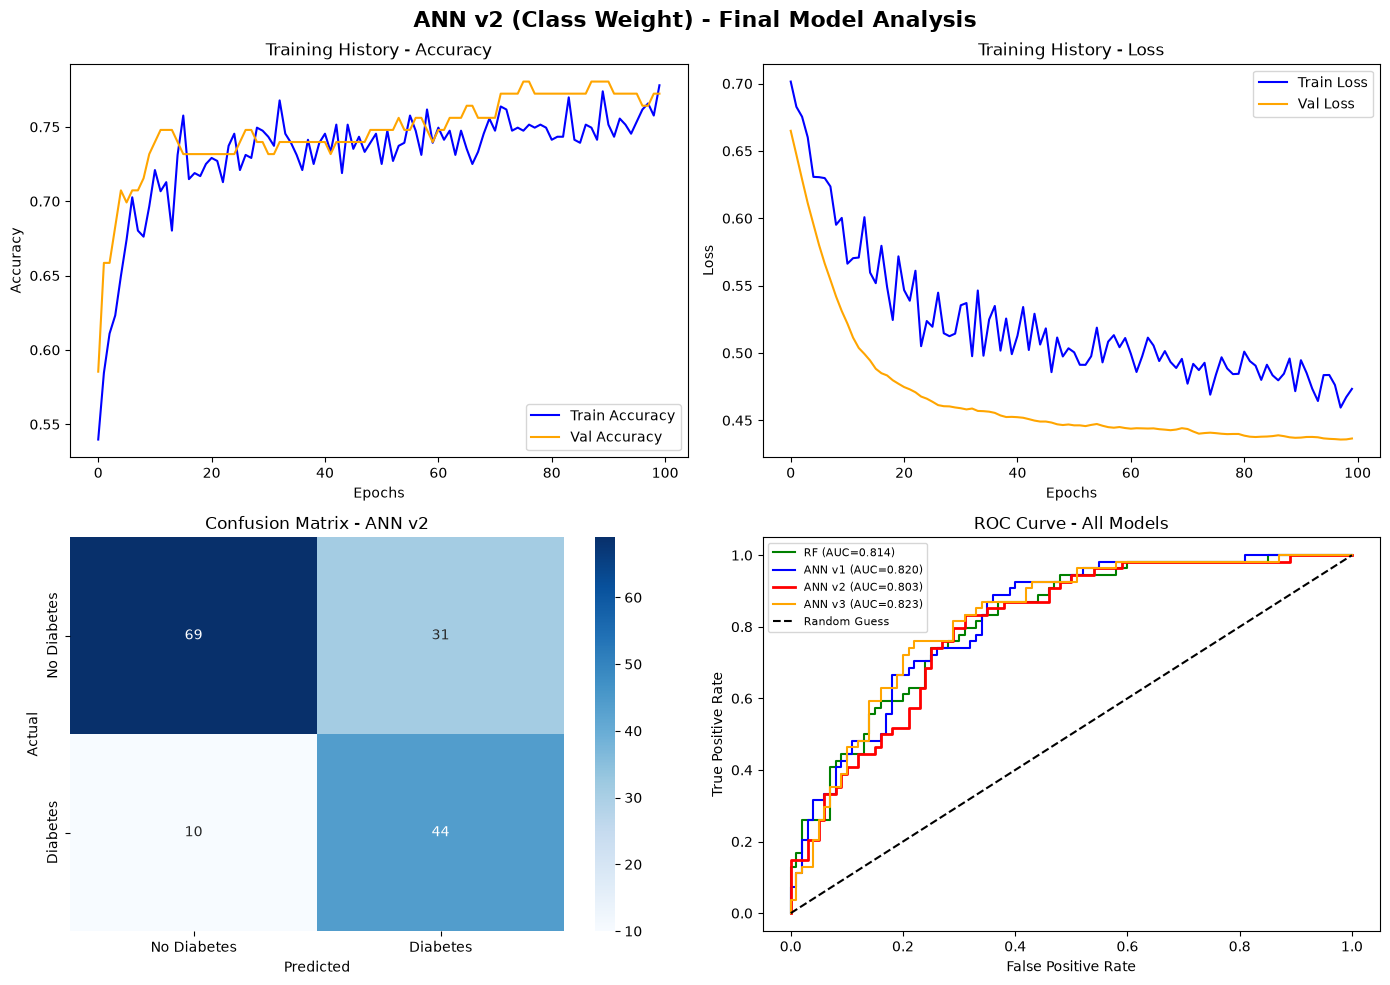

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, confusion_matrix

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ANN v2 (Class Weight) - Final Model Analysis', 
             fontsize=16, fontweight='bold')

# 1. Training History
axes[0, 0].plot(history_v2.history['accuracy'], 
                label='Train Accuracy', color='blue')
axes[0, 0].plot(history_v2.history['val_accuracy'], 
                label='Val Accuracy', color='orange')
axes[0, 0].set_title('Training History - Accuracy')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()

# 2. Loss History
axes[0, 1].plot(history_v2.history['loss'], 
                label='Train Loss', color='blue')
axes[0, 1].plot(history_v2.history['val_loss'], 
                label='Val Loss', color='orange')
axes[0, 1].set_title('Training History - Loss')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()

# 3. Confusion Matrix
cm = confusion_matrix(y_test, ann_pred_v2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
axes[1, 0].set_title('Confusion Matrix - ANN v2')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')
axes[1, 0].set_xticklabels(['No Diabetes', 'Diabetes'])
axes[1, 0].set_yticklabels(['No Diabetes', 'Diabetes'])

# 4. ROC Curve - All Models
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
ann_fpr, ann_tpr, _ = roc_curve(y_test, ann_prob)
ann_v2_fpr, ann_v2_tpr, _ = roc_curve(y_test, ann_prob_v2)
ann_v3_fpr, ann_v3_tpr, _ = roc_curve(y_test, ann_prob_v3)

axes[1, 1].plot(rf_fpr, rf_tpr, 
                label=f'RF (AUC={roc_auc_score(y_test, rf_prob):.3f})',
                color='green')
axes[1, 1].plot(ann_fpr, ann_tpr, 
                label=f'ANN v1 (AUC={roc_auc_score(y_test, ann_prob):.3f})',
                color='blue')
axes[1, 1].plot(ann_v2_fpr, ann_v2_tpr, 
                label=f'ANN v2 (AUC={roc_auc_score(y_test, ann_prob_v2):.3f})',
                color='red', linewidth=2)
axes[1, 1].plot(ann_v3_fpr, ann_v3_tpr, 
                label=f'ANN v3 (AUC={roc_auc_score(y_test, ann_prob_v3):.3f})',
                color='orange')
axes[1, 1].plot([0,1], [0,1], 'k--', label='Random Guess')
axes[1, 1].set_title('ROC Curve - All Models')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('final_model_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_8821/2286783099.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


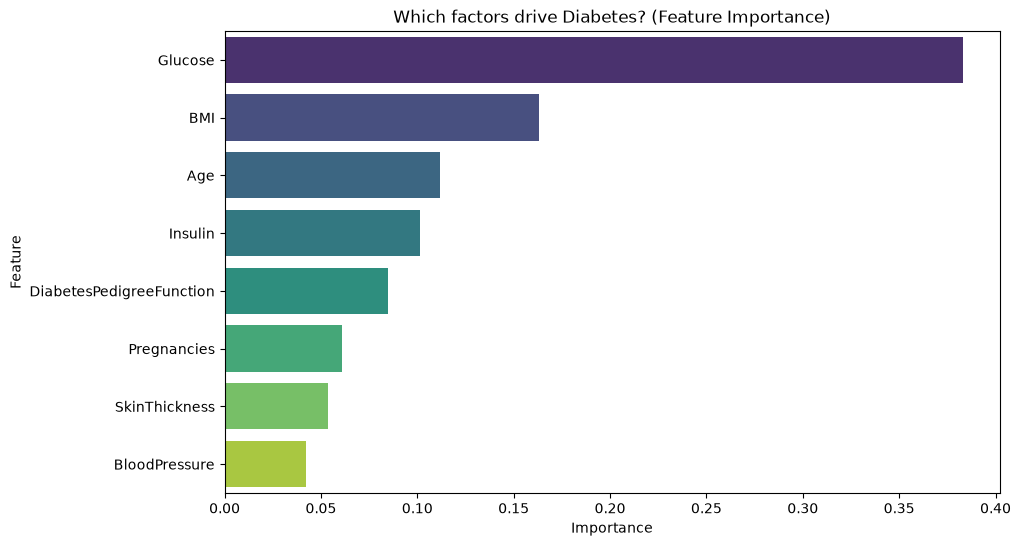

                    Feature  Importance
1                   Glucose    0.382953
5                       BMI    0.162874
7                       Age    0.111800
4                   Insulin    0.101291
6  DiabetesPedigreeFunction    0.084694
0               Pregnancies    0.060723
3             SkinThickness    0.053395
2             BloodPressure    0.042270


In [48]:
# Random Forest ki feature importance dekhte hain
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Which factors drive Diabetes? (Feature Importance)')
plt.show()

print(feature_importance_df)

In [49]:
import joblib

# ANN model save karo
ann_model_v2.save('diabetes_ann_model.h5')
print("✅ ANN Model saved!")

# Scaler save karo (bohot important!)
joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler saved!")

print("\nFiles created:")
print("→ diabetes_ann_model.h5")
print("→ scaler.pkl")

✅ ANN Model saved!
✅ Scaler saved!

Files created:
→ diabetes_ann_model.h5
→ scaler.pkl
